In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.stats import entropy
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report


In [2]:
# 1. Đọc dữ liệu
file_path = 'D:\\Code_File\\DAV\\final project\\original_file.csv'
df = pd.read_csv(file_path)

In [3]:
# Hàm tính toán đặc trưng hành vi cho 1 người trên 1 ảnh
def calculate_behavior(user_data, cluster_centers):
    if len(user_data) < 2: return [0, 0, 0]
    labels = cluster_centers.predict(user_data[['FIX_X', 'FIX_Y']])
    
    # 1. Calculate Entropy (Độ phân tán sự chú ý)
    # Nếu nhìn đều cả 4 vùng -> Entropy cao. Nếu chỉ nhìn 1 vùng -> Entropy thấp.
    value_counts = pd.Series(labels).value_counts(normalize=True)
    ent = entropy(value_counts)
    
    # 2. Calculate Transition Rate (Tần suất chuyển vùng)
    # Đếm số lần label thay đổi (đang nhìn vùng A chuyển sang vùng B)
    changes = sum(labels[i] != labels[i-1] for i in range(1, len(labels)))
    transition_rate = changes / len(labels)
    
    # 3. Thời gian trung bình tại mỗi vùng (Average Dwell Time)
    avg_dwell = user_data['FIX_DURATION'].mean()
    
    return [ent, transition_rate, avg_dwell]

In [4]:
# main loop
patient_behaviors = {} 
unique_images = df['image_id'].unique()
print(f"Đang xử lý {len(unique_images)} ảnh")

for img_id in unique_images:

    img_data = df[df['image_id'] == img_id].copy()
    
    if len(img_data) < 50: continue # Bỏ qua ảnh lỗi quá ít dữ liệu
    
    # BƯỚC A: TỰ ĐỘNG TÌM BỐ CỤC ẢNH (Dynamic ROIs)
    # Giả sử mỗi ảnh có tối đa 5 vùng quan trọng (bạn có thể chỉnh n_clusters=4 nếu ảnh 4 cảnh)
    kmeans_roi = KMeans(n_clusters=5, random_state=42, n_init=10)
    kmeans_roi.fit(img_data[['FIX_X', 'FIX_Y']])
    
    # BƯỚC B: TÍNH TOÁN HÀNH VI CHO TỪNG NGƯỜI TRÊN ẢNH NÀY
    for pid, group in img_data.groupby('numeric_id'):
        feats = calculate_behavior(group, kmeans_roi)
        
        if pid not in patient_behaviors:
            patient_behaviors[pid] = []
        patient_behaviors[pid].append(feats)

print("Đã trích xuất xong đặc trưng hành vi!")

Đang xử lý 100 ảnh
Đã trích xuất xong đặc trưng hành vi!


In [5]:
# AGGREGATION
# Vì mỗi bệnh nhân xem nhiều ảnh, ta tính trung bình các chỉ số hành vi này
final_features = []
patient_ids = []
true_labels = []

label_map = df.drop_duplicates('numeric_id').set_index('numeric_id')['label']

for pid, behavior_list in patient_behaviors.items():
    if len(behavior_list) == 0: continue
    
 
    behaviors = np.array(behavior_list)
    avg_behavior = np.mean(behaviors, axis=0)
    std_behavior = np.std(behaviors, axis=0) # Độ ổn định hành vi
    full_feat = np.concatenate([avg_behavior, std_behavior])
    
    final_features.append(full_feat)
    patient_ids.append(pid)
    true_labels.append(label_map[pid])

X = np.array(final_features)
y_true = np.array(true_labels)
feature_names = ['Mean_Entropy', 'Mean_SwitchRate', 'Mean_Duration', 
                 'Std_Entropy', 'Std_SwitchRate', 'Std_Duration']

In [6]:
# --- CLUSTERING ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Dùng K-Means đơn giản
kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=20)
clusters = kmeans_final.fit_predict(X_scaled)

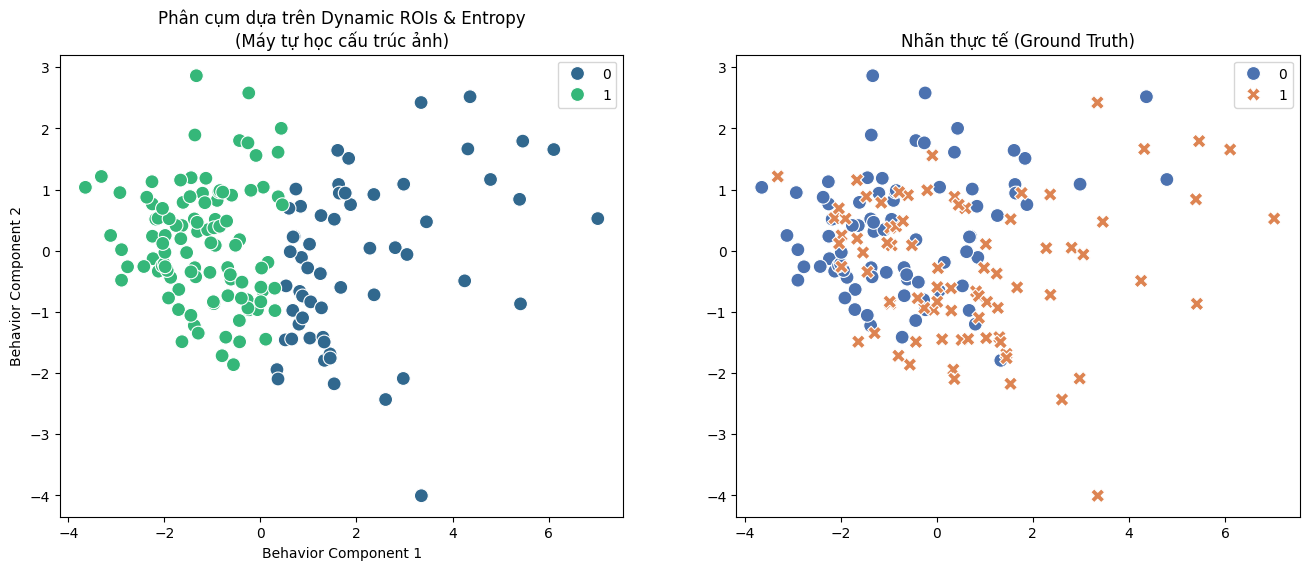

In [7]:
# --- VISUALIZATION ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(16, 6))

# Kết quả dự đoán
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters, palette='viridis', s=100)
plt.title('Phân cụm dựa trên Dynamic ROIs & Entropy\n(Máy tự học cấu trúc ảnh)')
plt.xlabel('Behavior Component 1')
plt.ylabel('Behavior Component 2')

# Kết quả thực tế
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_true, palette='deep', style=y_true, s=100)
plt.title('Nhãn thực tế (Ground Truth)')

plt.show()

In [8]:
# đánh giá
from sklearn.metrics import accuracy_score
if accuracy_score(y_true, clusters) < 0.5:
    clusters = 1 - clusters

print("\nClassification Report (Dynamic ROI Strategy):")
print(classification_report(y_true, clusters))
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X, y_true)
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print("\nCác yếu tố hành vi quan trọng nhất phân biệt bệnh nhân:")
print(importances)


Classification Report (Dynamic ROI Strategy):
              precision    recall  f1-score   support

           0       0.60      0.76      0.67        80
           1       0.67      0.49      0.57        80

    accuracy                           0.62       160
   macro avg       0.64      0.62      0.62       160
weighted avg       0.64      0.62      0.62       160


Các yếu tố hành vi quan trọng nhất phân biệt bệnh nhân:
Mean_SwitchRate    0.222644
Mean_Entropy       0.192929
Mean_Duration      0.180680
Std_Duration       0.140663
Std_Entropy        0.138673
Std_SwitchRate     0.124411
dtype: float64


Tổng số đặc trưng ban đầu: 908

--- BẮT ĐẦU QUÉT (Vui lòng đợi vài phút)... ---
Số Feature      | Accuracy Trung Bình 
----------------------------------------
10              | 68.12%
30              | 71.25%
50              | 72.50%
80              | 67.50%
100             | 67.50%
130             | 71.25%
160             | 68.75%
200             | 69.38%
300             | 71.25%
400             | 69.38%
500             | 73.12%
700             | 74.38%
908             | 74.38%

SỐ LƯỢNG ĐẶC TRƯNG TỐI ƯU (GOLDEN NUMBER): 700
   Độ chính xác cao nhất: 74.38%

 Đã lưu biểu đồ thành công: feature_optimization.jpg


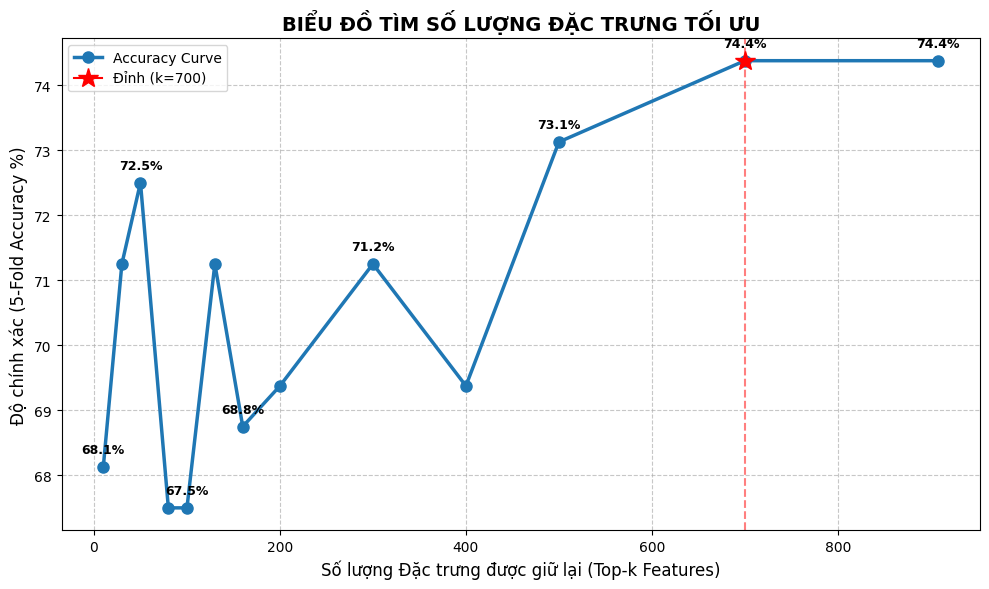

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings("ignore")

# 1. ĐỌC DỮ LIỆU
file_path = 'eye_tracking_features_k30_graph.csv'
df = pd.read_csv(file_path)


X = df.drop(columns=['label', 'numeric_id'], errors='ignore')
y = df['label']

print(f"Tổng số đặc trưng ban đầu: {X.shape[1]}")

# 2. THIẾT LẬP CÁC MỐC SỐ LƯỢNG ĐẶC TRƯNG CẦN THỬ
# Chúng ta sẽ quét từ 10, 20... đến hết
k_values = [10, 30, 50, 80, 100, 130, 160, 200, 300, 400, 500, 700, X.shape[1]]
mean_scores = []

# Dùng Gradient Boosting để dò tìm (Nó nhanh và nhạy với đặc trưng tốt)
# Bạn có thể thay bằng MLPClassifier nếu muốn, nhưng sẽ chạy lâu hơn
clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n--- BẮT ĐẦU QUÉT (Vui lòng đợi vài phút)... ---")
print(f"{'Số Feature':<15} | {'Accuracy Trung Bình':<20}")
print("-" * 40)

for k in k_values:
    # Pipeline chuẩn: Lọc k đặc trưng -> Chuẩn hóa -> Train
    # threshold=-np.inf nghĩa là: "Tôi không quan tâm ngưỡng điểm, cứ lấy đúng k cái cao nhất cho tôi"
    pipeline = Pipeline([
        ('selector', SelectFromModel(RandomForestClassifier(n_estimators=50, random_state=42), threshold=-np.inf, max_features=k)),
        ('scaler', StandardScaler()),
        ('classifier', clf)
    ])
    
    # Chạy Cross-Validation
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
    acc_mean = scores.mean() * 100
    mean_scores.append(acc_mean)
    
    print(f"{k:<15} | {acc_mean:.2f}%")

# 3. TÌM RA CON SỐ TỐI ƯU NHẤT
best_idx = np.argmax(mean_scores)
best_k = k_values[best_idx]
best_score = mean_scores[best_idx]

print("\n" + "="*50)
print(f"SỐ LƯỢNG ĐẶC TRƯNG TỐI ƯU (GOLDEN NUMBER): {best_k}")
print(f"   Độ chính xác cao nhất: {best_score:.2f}%")
print("="*50)

# 4. VẼ BIỂU ĐỒ (LINE CHART)
plt.figure(figsize=(10, 6))

# Vẽ đường chính
plt.plot(k_values, mean_scores, marker='o', linestyle='-', color='#1f77b4', linewidth=2.5, markersize=8, label='Accuracy Curve')

# Vẽ điểm cao nhất (Highlight)
plt.plot(best_k, best_score, marker='*', color='red', markersize=15, label=f'Đỉnh (k={best_k})')
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.5)

# Trang trí
plt.title('BIỂU ĐỒ TÌM SỐ LƯỢNG ĐẶC TRƯNG TỐI ƯU', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng Đặc trưng được giữ lại (Top-k Features)', fontsize=12)
plt.ylabel('Độ chính xác (5-Fold Accuracy %)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Hiển thị số liệu lên từng điểm
for i, txt in enumerate(mean_scores):
    # Chỉ hiện số nếu nó là đỉnh hoặc ở các mốc quan trọng để đỡ rối
    if k_values[i] == best_k or i % 2 == 0:
        plt.annotate(f"{txt:.1f}%", (k_values[i], mean_scores[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()

# Lưu ảnh để chèn vào LaTeX
save_name = 'feature_optimization.jpg'
plt.savefig(save_name, dpi=300)
print(f"\n Đã lưu biểu đồ thành công: {save_name}")
plt.show()